In [2]:
!pip install pytorch-tabnet -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

SEED = 42
np.random.seed(SEED)
WORK = '/kaggle/input/notebooks/mahmoudalwaqfi/datascience05pre-eda/'

X_train = pd.read_csv(f'{WORK}X_train_fe.csv')
X_val   = pd.read_csv(f'{WORK}X_val_fe.csv')
X_test  = pd.read_csv(f'{WORK}X_test_fe.csv')

y_train_cls = pd.read_csv(f'{WORK}y_train_cls.csv').squeeze()
y_val_cls   = pd.read_csv(f'{WORK}y_val_cls.csv').squeeze()
y_test_cls  = pd.read_csv(f'{WORK}y_test_cls.csv').squeeze()

y_train_reg = pd.read_csv(f'{WORK}y_train_reg.csv').squeeze()
y_val_reg   = pd.read_csv(f'{WORK}y_val_reg.csv').squeeze()
y_test_reg  = pd.read_csv(f'{WORK}y_test_reg.csv').squeeze()

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'Train delayed: {y_train_cls.mean():.3f} | Val: {y_val_cls.mean():.3f} | Test: {y_test_cls.mean():.3f}')
print('Data loaded ✅')

X_train: (170504, 26) | X_val: (30089, 26) | X_test: (99407, 26)
Train delayed: 0.226 | Val: 0.226 | Test: 0.194
Data loaded ✅


In [3]:
# ── Cell 2: Label Encoding ────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR',
    'DEST', 'DEST_STATE_ABR', 'CANCELLATION_CODE',
    'ROUTE', 'DIST_BIN', 'DEP_DELAY_BUCKET'
]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_train[col].astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_val[col]   = le.transform(
        X_val[col].astype(str).map(
            lambda x: x if x in le.classes_ else le.classes_[0]
        )
    )
    X_test[col]  = le.transform(
        X_test[col].astype(str).map(
            lambda x: x if x in le.classes_ else le.classes_[0]
        )
    )
    encoders[col] = le

print(f'Encoded {len(cat_cols)} categorical columns ✅')
print(f'X_train shape: {X_train.shape}')
print(f'Any nulls: {X_train.isnull().sum().sum()}')

Encoded 9 categorical columns ✅
X_train shape: (170504, 26)
Any nulls: 0


In [4]:
# ── Cell 3: XGBoost Classification ───────────────────────────
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score

imbalance_ratio = (y_train_cls == 0).sum() / (y_train_cls == 1).sum()

xgb_cls = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=imbalance_ratio,
    random_state=SEED,
    tree_method='hist',
    device='cuda',
    eval_metric='auc',
    verbosity=0
)

xgb_cls.fit(
    X_train, y_train_cls,
    eval_set=[(X_val, y_val_cls)],
    verbose=50
)

xgb_prob = xgb_cls.predict_proba(X_val)[:, 1]
xgb_auc  = roc_auc_score(y_val_cls, xgb_prob)
xgb_f1   = f1_score(y_val_cls, (xgb_prob >= 0.5).astype(int))

print(f'XGBoost Classification → AUC: {xgb_auc:.4f} | F1: {xgb_f1:.4f}')

[0]	validation_0-auc:0.91463
[50]	validation_0-auc:0.92294
[100]	validation_0-auc:0.92393
[150]	validation_0-auc:0.92420
[200]	validation_0-auc:0.92474
[250]	validation_0-auc:0.92518
[299]	validation_0-auc:0.92512
XGBoost Classification → AUC: 0.9251 | F1: 0.7827


In [6]:
# ── Cell 4: TabNet Classification (tuned) ────────────────────
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

tabnet_cls = TabNetClassifier(
    n_d=64, n_a=64,
    n_steps=5,
    gamma=1.3,
    n_independent=2,
    n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3, weight_decay=1e-5),
    scheduler_params=dict(step_size=20, gamma=0.9),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    seed=SEED,
    verbose=10
)

tabnet_cls.fit(
    X_train.values, y_train_cls.values,
    eval_set=[(X_val.values, y_val_cls.values)],
    eval_metric=['auc'],
    max_epochs=200,
    patience=30,
    batch_size=8192,
    virtual_batch_size=1024,
    weights=1
)

tabnet_prob = tabnet_cls.predict_proba(X_val.values)[:, 1]
tabnet_auc  = roc_auc_score(y_val_cls, tabnet_prob)
tabnet_f1   = f1_score(y_val_cls, (tabnet_prob >= 0.5).astype(int))

print(f'TabNet Classification → AUC: {tabnet_auc:.4f} | F1: {tabnet_f1:.4f}')

epoch 0  | loss: 0.65322 | val_0_auc: 0.495   |  0:00:03s
epoch 10 | loss: 0.2847  | val_0_auc: 0.52506 |  0:00:23s
epoch 20 | loss: 0.27814 | val_0_auc: 0.59608 |  0:00:44s
epoch 30 | loss: 0.27193 | val_0_auc: 0.83327 |  0:01:04s
epoch 40 | loss: 0.26372 | val_0_auc: 0.91359 |  0:01:25s
epoch 50 | loss: 0.25719 | val_0_auc: 0.92012 |  0:01:45s
epoch 60 | loss: 0.24991 | val_0_auc: 0.91667 |  0:02:06s
epoch 70 | loss: 0.24412 | val_0_auc: 0.91619 |  0:02:26s

Early stopping occurred at epoch 76 with best_epoch = 46 and best_val_0_auc = 0.92279
TabNet Classification → AUC: 0.9228 | F1: 0.7617


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# ── Logistic Regression ───────────────────────────────────────
lr_cls = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr_cls.fit(X_train, y_train_cls)
lr_prob = lr_cls.predict_proba(X_val)[:, 1]
lr_auc  = roc_auc_score(y_val_cls, lr_prob)
lr_f1   = f1_score(y_val_cls, (lr_prob >= 0.5).astype(int))
print(f'Logistic Regression → AUC: {lr_auc:.4f} | F1: {lr_f1:.4f}')

# ── Random Forest ─────────────────────────────────────────────
rf_cls = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf_cls.fit(X_train, y_train_cls)
rf_prob = rf_cls.predict_proba(X_val)[:, 1]
rf_auc  = roc_auc_score(y_val_cls, rf_prob)
rf_f1   = f1_score(y_val_cls, (rf_prob >= 0.5).astype(int))
print(f'Random Forest       → AUC: {rf_auc:.4f} | F1: {rf_f1:.4f}')

# ── LightGBM ──────────────────────────────────────────────────
lgbm_cls = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    num_leaves=63, class_weight='balanced',
    random_state=SEED, verbosity=-1
)
lgbm_cls.fit(X_train, y_train_cls)
lgbm_prob = lgbm_cls.predict_proba(X_val)[:, 1]
lgbm_auc  = roc_auc_score(y_val_cls, lgbm_prob)
lgbm_f1   = f1_score(y_val_cls, (lgbm_prob >= 0.5).astype(int))
print(f'LightGBM            → AUC: {lgbm_auc:.4f} | F1: {lgbm_f1:.4f}')


Logistic Regression → AUC: 0.9260 | F1: 0.7826
Random Forest       → AUC: 0.9274 | F1: 0.7946
LightGBM            → AUC: 0.9241 | F1: 0.7791


In [9]:
thresholds = np.arange(0.10, 0.90, 0.01)

best_thresholds = {}
for name, prob in [
    ('Logistic Regression', lr_prob),
    ('Random Forest',       rf_prob),
    ('LightGBM',            lgbm_prob),
    ('XGBoost',             xgb_prob),
    ('TabNet',              tabnet_prob),
]:
    f1_scores  = [f1_score(y_val_cls, (prob >= t).astype(int)) for t in thresholds]
    best_t     = thresholds[np.argmax(f1_scores)]
    best_f1    = max(f1_scores)
    default_f1 = f1_score(y_val_cls, (prob >= 0.5).astype(int))
    best_thresholds[name] = best_t
    print(f'{name:<22} → threshold: {best_t:.2f} | default F1: {default_f1:.4f} → optimized F1: {best_f1:.4f} (+{best_f1-default_f1:.4f})')

Logistic Regression    → threshold: 0.77 | default F1: 0.7826 → optimized F1: 0.8097 (+0.0272)
Random Forest          → threshold: 0.41 | default F1: 0.7946 → optimized F1: 0.8001 (+0.0055)
LightGBM               → threshold: 0.72 | default F1: 0.7791 → optimized F1: 0.8047 (+0.0256)
XGBoost                → threshold: 0.74 | default F1: 0.7827 → optimized F1: 0.8065 (+0.0238)
TabNet                 → threshold: 0.78 | default F1: 0.7617 → optimized F1: 0.8014 (+0.0398)


In [10]:
from sklearn.linear_model import LogisticRegression as LR

# Level 1 — val probabilities from all 5 models
stack_val = np.column_stack([lr_prob, rf_prob, lgbm_prob, xgb_prob, tabnet_prob])

# Meta learner trained on val
meta_cls = LR(random_state=SEED, max_iter=1000)
meta_cls.fit(stack_val, y_val_cls)

stack_prob = meta_cls.predict_proba(stack_val)[:, 1]
stack_auc  = roc_auc_score(y_val_cls, stack_prob)
stack_f1   = f1_score(y_val_cls, (stack_prob >= 0.5).astype(int))

print(f'Stacking Ensemble → AUC: {stack_auc:.4f} | F1: {stack_f1:.4f}')
print(f'Meta learner weights: {dict(zip(["LR","RF","LGBM","XGB","TabNet"], meta_cls.coef_[0].round(3)))}')

Stacking Ensemble → AUC: 0.9336 | F1: 0.8101
Meta learner weights: {'LR': np.float64(2.393), 'RF': np.float64(3.829), 'LGBM': np.float64(0.158), 'XGB': np.float64(0.424), 'TabNet': np.float64(0.272)}


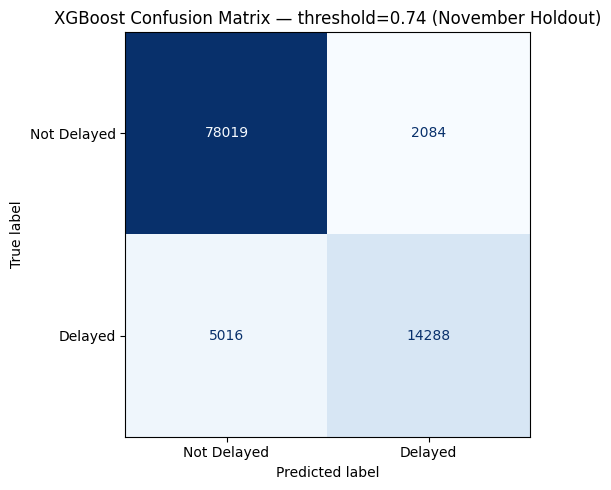

TN: 78,019 | FP: 2,084 | FN: 5,016 | TP: 14,288
Recall (Delayed)  : 0.740
False Alarm Rate  : 0.026
Missed delays     : 5,016 out of 19,304


In [16]:
xgb_test_prob = xgb_cls.predict_proba(X_test)[:, 1]
best_thresh    = best_thresholds['XGBoost']
y_pred_test    = (xgb_test_prob >= best_thresh).astype(int)

cm = confusion_matrix(y_test_cls, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Not Delayed','Delayed']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'XGBoost Confusion Matrix — threshold={best_thresh:.2f} (November Holdout)')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN: {tn:,} | FP: {fp:,} | FN: {fn:,} | TP: {tp:,}')
print(f'Recall (Delayed)  : {tp/(tp+fn):.3f}')
print(f'False Alarm Rate  : {fp/(fp+tn):.3f}')
print(f'Missed delays     : {fn:,} out of {fn+tp:,}')

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

# ── Linear Regression ─────────────────────────────────────────
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train_reg)
lr_pred = lr_reg.predict(X_val)
print(f'Linear Regression → RMSE: {np.sqrt(mean_squared_error(y_val_reg, lr_pred)):.4f} | MAE: {mean_absolute_error(y_val_reg, lr_pred):.4f} | R²: {r2_score(y_val_reg, lr_pred):.4f}')

# ── Random Forest ─────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)
rf_pred = rf_reg.predict(X_val)
print(f'Random Forest     → RMSE: {np.sqrt(mean_squared_error(y_val_reg, rf_pred)):.4f} | MAE: {mean_absolute_error(y_val_reg, rf_pred):.4f} | R²: {r2_score(y_val_reg, rf_pred):.4f}')

# ── LightGBM ──────────────────────────────────────────────────
lgbm_reg = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=SEED, verbosity=-1)
lgbm_reg.fit(X_train, y_train_reg)
lgbm_pred = lgbm_reg.predict(X_val)
print(f'LightGBM          → RMSE: {np.sqrt(mean_squared_error(y_val_reg, lgbm_pred)):.4f} | MAE: {mean_absolute_error(y_val_reg, lgbm_pred):.4f} | R²: {r2_score(y_val_reg, lgbm_pred):.4f}')

# ── XGBoost ───────────────────────────────────────────────────
xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    random_state=SEED, tree_method='hist', device='cuda', verbosity=0
)
xgb_reg.fit(X_train, y_train_reg, eval_set=[(X_val, y_val_reg)], verbose=50)
xgb_reg_pred = xgb_reg.predict(X_val)
print(f'XGBoost           → RMSE: {np.sqrt(mean_squared_error(y_val_reg, xgb_reg_pred)):.4f} | MAE: {mean_absolute_error(y_val_reg, xgb_reg_pred):.4f} | R²: {r2_score(y_val_reg, xgb_reg_pred):.4f}')

Linear Regression → RMSE: 15.6397 | MAE: 10.4053 | R²: 0.8687
Random Forest     → RMSE: 15.0511 | MAE: 10.3030 | R²: 0.8784
LightGBM          → RMSE: 14.5309 | MAE: 9.8913 | R²: 0.8867
[0]	validation_0-rmse:41.27165
[50]	validation_0-rmse:15.11845
[100]	validation_0-rmse:14.73062
[150]	validation_0-rmse:14.64405
[200]	validation_0-rmse:14.58434
[250]	validation_0-rmse:14.55128
[299]	validation_0-rmse:14.52582
XGBoost           → RMSE: 14.5258 | MAE: 9.8742 | R²: 0.8868


In [14]:
from pytorch_tabnet.tab_model import TabNetRegressor

tabnet_reg = TabNetRegressor(
    n_d=64, n_a=64,
    n_steps=5,
    gamma=1.3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3, weight_decay=1e-5),
    scheduler_params=dict(step_size=20, gamma=0.9),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=SEED,
    verbose=10
)

tabnet_reg.fit(
    X_train.values, y_train_reg.values.reshape(-1, 1),
    eval_set=[(X_val.values, y_val_reg.values.reshape(-1, 1))],
    eval_metric=['rmse'],
    max_epochs=100,
    patience=20,
    batch_size=8192,
    virtual_batch_size=1024
)

tabnet_reg_pred = tabnet_reg.predict(X_val.values).flatten()
print(f'TabNet Regression → RMSE: {np.sqrt(mean_squared_error(y_val_reg, tabnet_reg_pred)):.4f} | MAE: {mean_absolute_error(y_val_reg, tabnet_reg_pred):.4f} | R²: {r2_score(y_val_reg, tabnet_reg_pred):.4f}')

epoch 0  | loss: 1620.25444| val_0_rmse: 1058.69086|  0:00:02s
epoch 10 | loss: 233.6804| val_0_rmse: 129.05194|  0:00:29s
epoch 20 | loss: 226.76392| val_0_rmse: 38.41367|  0:00:55s
epoch 30 | loss: 221.99856| val_0_rmse: 42.25381|  0:01:21s
epoch 40 | loss: 216.86056| val_0_rmse: 16.52547|  0:01:48s
epoch 50 | loss: 213.46518| val_0_rmse: 15.02432|  0:02:14s
epoch 60 | loss: 213.74599| val_0_rmse: 14.96445|  0:02:41s
epoch 70 | loss: 215.28957| val_0_rmse: 15.02949|  0:03:07s
epoch 80 | loss: 211.63293| val_0_rmse: 14.92917|  0:03:34s
epoch 90 | loss: 210.34641| val_0_rmse: 14.93708|  0:04:00s

Early stopping occurred at epoch 99 with best_epoch = 79 and best_val_0_rmse = 14.89341
TabNet Regression → RMSE: 14.8934 | MAE: 10.1273 | R²: 0.8810


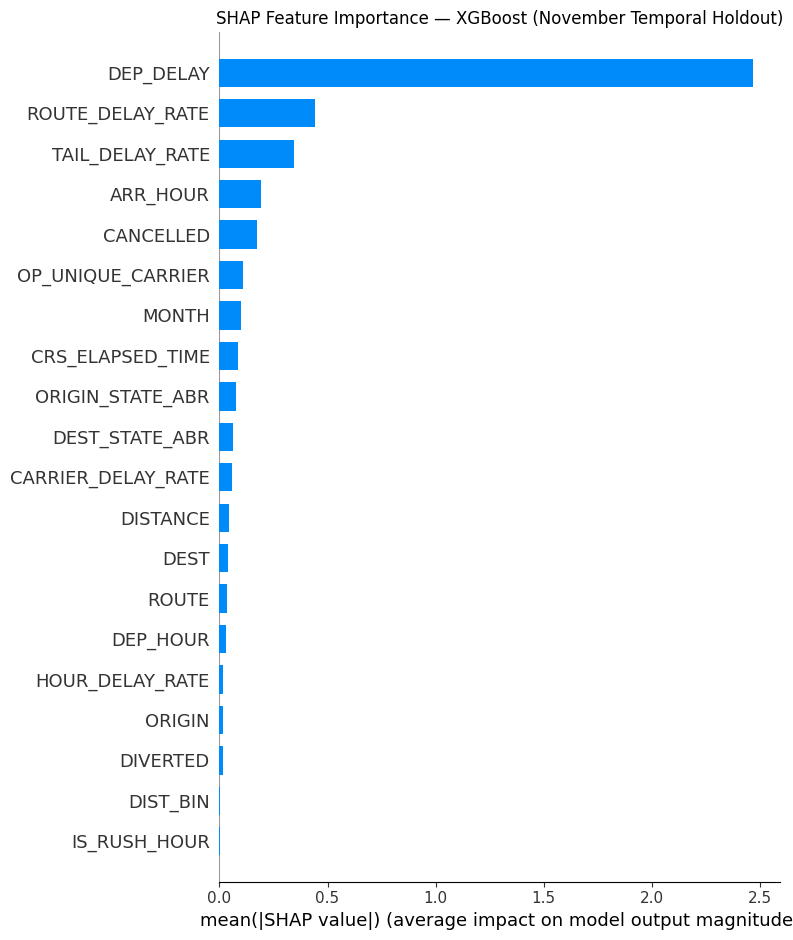

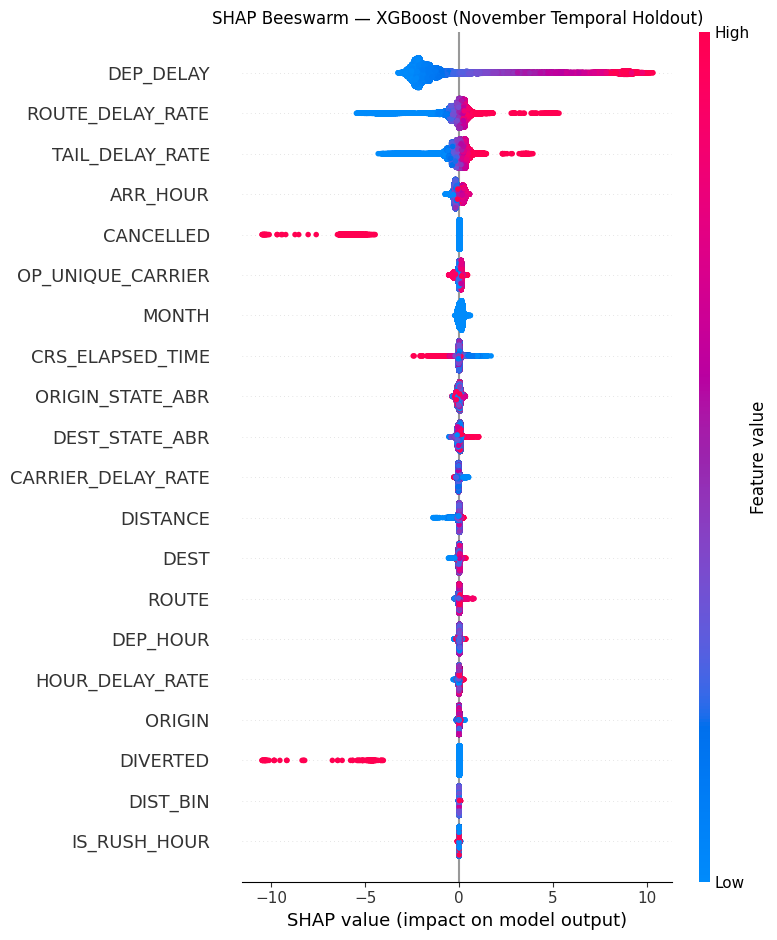

In [15]:
import shap

explainer   = shap.TreeExplainer(xgb_cls)
shap_values = explainer.shap_values(X_test)   # November holdout

# Bar chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost (November Temporal Holdout)')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_bar_temporal.png', dpi=150)
plt.show()

# Beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm — XGBoost (November Temporal Holdout)')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_beeswarm_temporal.png', dpi=150)
plt.show()

In [37]:
print("="*60)
print("  FINAL EVALUATION — NOVEMBER TEMPORAL HOLDOUT")
print("="*60)

# ── Classification ────────────────────────────────────────────
print("\n── CLASSIFICATION ──")
cls_results = {}

for name, model, prob_fn, is_tabnet in [
    ('Logistic Regression', lr_cls,    lambda m: m.predict_proba(X_test)[:,1],        False),
    ('Random Forest',       rf_cls,    lambda m: m.predict_proba(X_test)[:,1],        False),
    ('LightGBM',            lgbm_cls,  lambda m: m.predict_proba(X_test)[:,1],        False),
    ('XGBoost',             xgb_cls,   lambda m: m.predict_proba(X_test)[:,1],        False),
    ('TabNet',              tabnet_cls,lambda m: m.predict_proba(X_test.values)[:,1], True),
]:
    prob  = prob_fn(model)
    thresh = best_thresholds[name]
    pred  = (prob >= thresh).astype(int)
    cls_results[name] = {
        'AUC'      : round(roc_auc_score(y_test_cls, prob), 4),
        'F1'       : round(f1_score(y_test_cls, pred), 4),
        'Precision': round(precision_score(y_test_cls, pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test_cls, pred, zero_division=0), 4),
        'Threshold': round(thresh, 2)
    }

# Stacking test
stack_test = np.column_stack([
    lr_cls.predict_proba(X_test)[:,1],
    rf_cls.predict_proba(X_test)[:,1],
    lgbm_cls.predict_proba(X_test)[:,1],
    xgb_cls.predict_proba(X_test)[:,1],
    tabnet_cls.predict_proba(X_test.values)[:,1]
])
stack_test_prob = meta_cls.predict_proba(stack_test)[:,1]
stack_thresh    = thresholds[np.argmax([f1_score(y_val_cls, (stack_prob >= t).astype(int)) for t in thresholds])]
cls_results['Stacking Ensemble'] = {
    'AUC'      : round(roc_auc_score(y_test_cls, stack_test_prob), 4),
    'F1'       : round(f1_score(y_test_cls, (stack_test_prob >= stack_thresh).astype(int)), 4),
    'Precision': round(precision_score(y_test_cls, (stack_test_prob >= stack_thresh).astype(int), zero_division=0), 4),
    'Recall'   : round(recall_score(y_test_cls, (stack_test_prob >= stack_thresh).astype(int), zero_division=0), 4),
    'Threshold': round(stack_thresh, 2)
}

df_cls = pd.DataFrame(cls_results).T.sort_values('AUC', ascending=False)
print(df_cls.to_string())

# ── Regression ────────────────────────────────────────────────
print("\n── REGRESSION ──")
reg_results = {}

for name, model, is_tabnet in [
    ('Linear Regression', lr_reg,      False),
    ('Random Forest',     rf_reg,      False),
    ('LightGBM',          lgbm_reg,    False),
    ('XGBoost',           xgb_reg,     False),
    ('TabNet',            tabnet_reg,  True),
]:
    pred = model.predict(X_test.values).flatten() if is_tabnet else model.predict(X_test)
    reg_results[name] = {
        'RMSE': round(np.sqrt(mean_squared_error(y_test_reg, pred)), 4),
        'MAE' : round(mean_absolute_error(y_test_reg, pred), 4),
        'R²'  : round(r2_score(y_test_reg, pred), 4),
    }

df_reg = pd.DataFrame(reg_results).T.sort_values('R²', ascending=False)
print(df_reg.to_string())

print("\n✅ Final evaluation complete — November test set touched once")

  FINAL EVALUATION — NOVEMBER TEMPORAL HOLDOUT

── CLASSIFICATION ──
                        AUC      F1  Precision  Recall  Threshold
Stacking Ensemble    0.9295  0.8070     0.8722  0.7509       0.53
Logistic Regression  0.9290  0.8097     0.8633  0.7623       0.77
Random Forest        0.9197  0.7984     0.8590  0.7458       0.41
XGBoost              0.9185  0.8010     0.8727  0.7402       0.74
LightGBM             0.9159  0.7988     0.8630  0.7436       0.72
TabNet               0.9094  0.7921     0.8601  0.7340       0.78

── REGRESSION ──
                      RMSE      MAE      R²
LightGBM           14.2618  10.0988  0.8775
XGBoost            14.2963  10.1113  0.8769
Random Forest      14.8947  10.6248  0.8664
TabNet             14.9388  10.7014  0.8656
Linear Regression  15.2132  11.0572  0.8606

✅ Final evaluation complete — November test set touched once


In [38]:
import zipfile, os

WORK2 = '/kaggle/input/notebooks/mahmoudalwaqfi/datascience05pre-eda/'
DEC_PATH = '/kaggle/input/datasets/mahmoudalwaqfi/aftere/'

# ── Load December raw ─────────────────────────────────────────
dec_files = [f for f in os.listdir(DEC_PATH) if '12' in f]
print(f'December files found: {dec_files}')

# Load — handle both CSV and ZIP
dec_file = dec_files[0]
if dec_file.endswith('.zip'):
    with zipfile.ZipFile(os.path.join(DEC_PATH, dec_file)) as z:
        csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
        with z.open(csv_name) as f:
            df_dec = pd.read_csv(f, low_memory=False)
else:
    df_dec = pd.read_csv(os.path.join(DEC_PATH, dec_file), low_memory=False)

print(f'December raw shape: {df_dec.shape}')
print(f'Columns: {list(df_dec.columns)}')

December files found: ['T_ONTIME_REPORTING12.csv']
December raw shape: (582304, 35)
Columns: ['YEAR', 'MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_GROUP', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_GROUP', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']


In [39]:
# ── Load winsorization bounds from Notebook 1 ────────────────
bounds = pd.read_csv(f'{WORK2}winsor_bounds.csv')
dep_lower = bounds.loc[bounds['col']=='DEP_DELAY', 'lower'].values[0]
dep_upper = bounds.loc[bounds['col']=='DEP_DELAY', 'upper'].values[0]
arr_lower = bounds.loc[bounds['col']=='ARR_DELAY', 'lower'].values[0]
arr_upper = bounds.loc[bounds['col']=='ARR_DELAY', 'upper'].values[0]

print(f'DEP bounds: [{dep_lower}, {dep_upper}]')
print(f'ARR bounds: [{arr_lower}, {arr_upper}]')

DEP bounds: [-15.0, 226.0]
ARR bounds: [-37.0, 226.0]


In [40]:
# ── Preprocess December (same pipeline as Notebook 1) ────────
df_dec['IS_CANCELLED'] = df_dec['CANCELLED'].fillna(0).astype(int)

df_dec['DEP_TIME'] = df_dec['DEP_TIME'].fillna(df_dec['CRS_DEP_TIME'])
df_dec['ARR_TIME'] = df_dec['ARR_TIME'].fillna(df_dec['CRS_ARR_TIME'])
df_dec['ARR_DELAY'] = df_dec['ARR_DELAY'].fillna(0)
df_dec['DEP_DELAY'] = df_dec['DEP_DELAY'].fillna(0)
df_dec['AIR_TIME'] = df_dec['AIR_TIME'].fillna(0)

df_dec['CANCELLATION_CODE'] = df_dec['CANCELLATION_CODE'].fillna('N')
df_dec['TAIL_NUM'] = df_dec['TAIL_NUM'].fillna('UNKNOWN')

for col in ['CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','SECURITY_DELAY','LATE_AIRCRAFT_DELAY']:
    df_dec[col] = df_dec[col].fillna(0)

df_dec['CRS_ELAPSED_TIME'] = df_dec['CRS_ELAPSED_TIME'].fillna(df_dec['CRS_ELAPSED_TIME'].median()).abs()
df_dec['DEP_TIME'] = df_dec['DEP_TIME'].clip(0, 2359)
df_dec['ARR_TIME'] = df_dec['ARR_TIME'].clip(0, 2359)

# Winsorize using TRAINING bounds — never recompute on December
df_dec['DEP_DELAY'] = df_dec['DEP_DELAY'].clip(dep_lower, dep_upper)
df_dec['ARR_DELAY'] = df_dec['ARR_DELAY'].clip(arr_lower, arr_upper)

df_dec['IS_DELAYED'] = (df_dec['ARR_DELAY'] > 15).astype(int)

print(f'December preprocessed: {df_dec.shape}')
print(f'Missing values: {df_dec.isnull().sum().sum()}')
print(f'IS_DELAYED: {df_dec["IS_DELAYED"].value_counts(normalize=True).round(4).to_dict()}')

December preprocessed: (582304, 37)
Missing values: 19026
IS_DELAYED: {0: 0.7446, 1: 0.2554}


In [41]:
df_dec['DEP_DELAY_GROUP'] = df_dec['DEP_DELAY_GROUP'].fillna(0)
df_dec['ARR_DELAY_GROUP'] = df_dec['ARR_DELAY_GROUP'].fillna(0)
df_dec = df_dec.fillna(0)  # catch any remaining
print(f'Missing after fix: {df_dec.isnull().sum().sum()}')

Missing after fix: 0


In [42]:
# ── Feature Engineering on December ──────────────────────────
# Load encoding maps from Notebook 1 — never recompute
global_rate  = pd.read_csv(f'{WORK2}global_rate.csv').values[0][0]
carrier_map  = pd.read_csv(f'{WORK2}carrier_map.csv', index_col=0).squeeze()
route_map    = pd.read_csv(f'{WORK2}route_map.csv',   index_col=0).squeeze()
tail_map     = pd.read_csv(f'{WORK2}tail_map.csv',    index_col=0).squeeze()
hour_map     = pd.read_csv(f'{WORK2}hour_map.csv',    index_col=0).squeeze()

print(f'Global rate: {global_rate:.4f}')

# Base features
df_dec['DEP_HOUR']         = (df_dec['CRS_DEP_TIME'] // 100).clip(0, 23)
df_dec['ARR_HOUR']         = (df_dec['CRS_ARR_TIME'] // 100).clip(0, 23)
df_dec['IS_RUSH_HOUR']     = df_dec['DEP_HOUR'].isin([7,8,9,17,18,19,20]).astype(int)
df_dec['IS_EARLY_MORNING'] = (df_dec['DEP_HOUR'] <= 5).astype(int)
df_dec['ROUTE']            = df_dec['ORIGIN'].astype(str) + '_' + df_dec['DEST'].astype(str)
df_dec['IS_DEP_LATE']      = (df_dec['DEP_DELAY'] > 0).astype(int)
df_dec['DEP_DELAY_BUCKET'] = pd.cut(
    df_dec['DEP_DELAY'],
    bins=[-999, -1, 5, 30, 60, 999],
    labels=['early','slight','moderate','severe','extreme']
).astype(str)
df_dec['DIST_BIN'] = pd.cut(
    df_dec['DISTANCE'],
    bins=[0, 500, 1000, 2000, 9999],
    labels=['short','medium','long','ultra']
).astype(str)

# Rate encodings — from training maps only
df_dec['CARRIER_DELAY_RATE'] = df_dec['OP_UNIQUE_CARRIER'].map(carrier_map).fillna(global_rate)
df_dec['ROUTE_DELAY_RATE']   = df_dec['ROUTE'].map(route_map).fillna(global_rate)
df_dec['TAIL_DELAY_RATE']    = df_dec['TAIL_NUM'].map(tail_map).fillna(global_rate)
df_dec['HOUR_DELAY_RATE']    = df_dec['DEP_HOUR'].map(hour_map).fillna(global_rate)

# Coverage check
tail_cov  = df_dec['TAIL_NUM'].isin(tail_map.index).mean()
route_cov = df_dec['ROUTE'].isin(route_map.index).mean()
print(f'Dec tail coverage  : {tail_cov:.1%}')
print(f'Dec route coverage : {route_cov:.1%}')
print('Feature engineering complete ✅')

Global rate: 0.2255
Dec tail coverage  : 96.5%
Dec route coverage : 99.3%
Feature engineering complete ✅


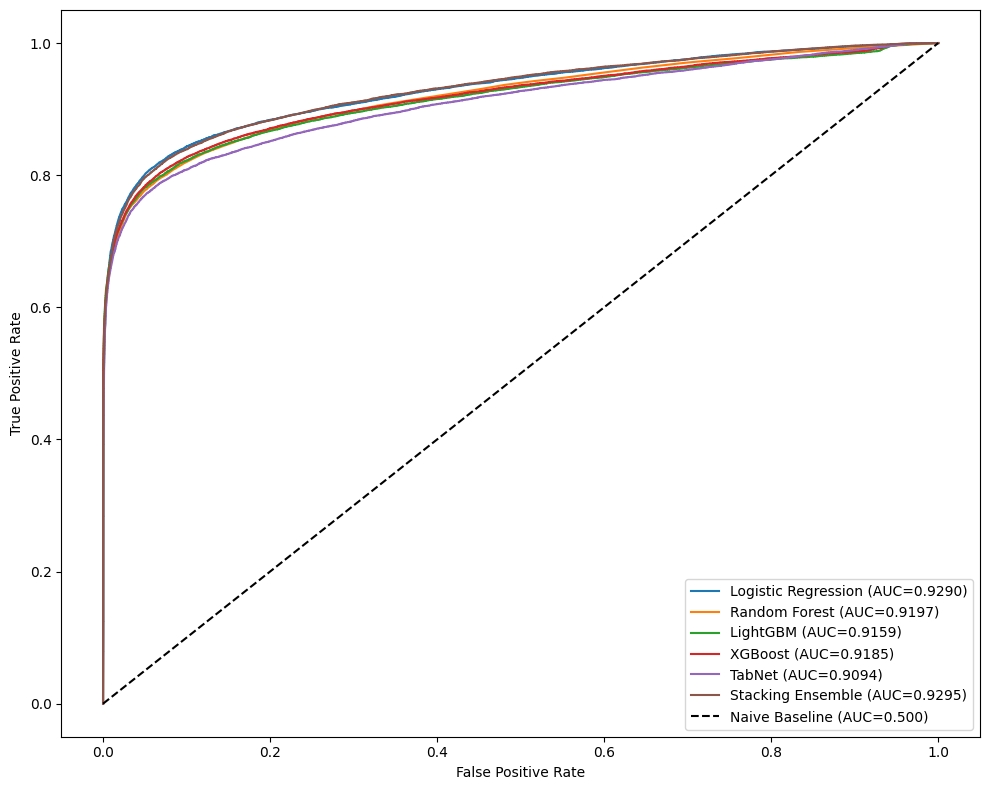

Saved ✅


In [43]:
fig, ax = plt.subplots(figsize=(10, 8))

models_probs = {
    'Logistic Regression': lr_cls.predict_proba(X_test)[:, 1],
    'Random Forest':       rf_cls.predict_proba(X_test)[:, 1],
    'LightGBM':            lgbm_cls.predict_proba(X_test)[:, 1],
    'XGBoost':             xgb_cls.predict_proba(X_test)[:, 1],
    'TabNet':              tabnet_cls.predict_proba(X_test.values)[:, 1],
    'Stacking Ensemble':   meta_cls.predict_proba(
                               np.column_stack([
                                   lr_cls.predict_proba(X_test)[:, 1],
                                   rf_cls.predict_proba(X_test)[:, 1],
                                   lgbm_cls.predict_proba(X_test)[:, 1],
                                   xgb_cls.predict_proba(X_test)[:, 1],
                                   tabnet_cls.predict_proba(X_test.values)[:, 1]
                               ])
                           )[:, 1],
}

for name, prob in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test_cls, prob)
    score = roc_auc_score(y_test_cls, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={score:.4f})')

ax.plot([0,1],[0,1],'k--', label='Naive Baseline (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Classifiers (November Temporal Holdout)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

In [44]:
# ── Label Encode December using training encoders ─────────────
FEATURE_COLS = [
    'YEAR', 'MONTH', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR',
    'DEST', 'DEST_STATE_ABR', 'DEP_DELAY', 'CANCELLED', 'CANCELLATION_CODE',
    'DIVERTED', 'CRS_ELAPSED_TIME', 'DISTANCE', 'DEP_HOUR', 'ARR_HOUR',
    'ROUTE', 'DIST_BIN', 'IS_CANCELLED', 'IS_RUSH_HOUR', 'IS_EARLY_MORNING',
    'CARRIER_DELAY_RATE', 'ROUTE_DELAY_RATE', 'IS_DEP_LATE', 'DEP_DELAY_BUCKET',
    'TAIL_DELAY_RATE', 'HOUR_DELAY_RATE'
]

cat_cols = [
    'OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR',
    'DEST', 'DEST_STATE_ABR', 'CANCELLATION_CODE',
    'ROUTE', 'DIST_BIN', 'DEP_DELAY_BUCKET'
]

X_dec = df_dec[FEATURE_COLS].copy()
y_dec_cls = df_dec['IS_DELAYED'].copy()
y_dec_reg = df_dec['ARR_DELAY'].copy()

for col in cat_cols:
    le = encoders[col]
    X_dec[col] = X_dec[col].astype(str).map(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
    X_dec[col] = le.transform(X_dec[col])

print(f'X_dec shape: {X_dec.shape}')
print(f'Missing values: {X_dec.isnull().sum().sum()}')
print(f'December IS_DELAYED: {y_dec_cls.mean():.3f}')
print('December ready for prediction ✅')

X_dec shape: (582304, 26)
Missing values: 0
December IS_DELAYED: 0.255
December ready for prediction ✅


In [45]:
print("="*60)
print("  FINAL EVALUATION — DECEMBER TEMPORAL HOLDOUT")
print("="*60)

# ── Classification ────────────────────────────────────────────
print("\n── CLASSIFICATION ──")
dec_cls_results = {}

for name, model, is_tabnet in [
    ('Logistic Regression', lr_cls,    False),
    ('Random Forest',       rf_cls,    False),
    ('LightGBM',            lgbm_cls,  False),
    ('XGBoost',             xgb_cls,   False),
    ('TabNet',              tabnet_cls, True),
]:
    prob  = model.predict_proba(X_dec.values if is_tabnet else X_dec)[:,1]
    thresh = best_thresholds[name]
    pred  = (prob >= thresh).astype(int)
    dec_cls_results[name] = {
        'AUC'      : round(roc_auc_score(y_dec_cls, prob), 4),
        'F1'       : round(f1_score(y_dec_cls, pred), 4),
        'Precision': round(precision_score(y_dec_cls, pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_dec_cls, pred, zero_division=0), 4),
        'Threshold': round(thresh, 2)
    }

# Stacking
stack_dec = np.column_stack([
    lr_cls.predict_proba(X_dec)[:,1],
    rf_cls.predict_proba(X_dec)[:,1],
    lgbm_cls.predict_proba(X_dec)[:,1],
    xgb_cls.predict_proba(X_dec)[:,1],
    tabnet_cls.predict_proba(X_dec.values)[:,1]
])
stack_dec_prob = meta_cls.predict_proba(stack_dec)[:,1]
stack_pred     = (stack_dec_prob >= stack_thresh).astype(int)
dec_cls_results['Stacking Ensemble'] = {
    'AUC'      : round(roc_auc_score(y_dec_cls, stack_dec_prob), 4),
    'F1'       : round(f1_score(y_dec_cls, stack_pred), 4),
    'Precision': round(precision_score(y_dec_cls, stack_pred, zero_division=0), 4),
    'Recall'   : round(recall_score(y_dec_cls, stack_pred, zero_division=0), 4),
    'Threshold': round(stack_thresh, 2)
}

df_dec_cls = pd.DataFrame(dec_cls_results).T.sort_values('AUC', ascending=False)
print(df_dec_cls.to_string())

# ── Regression ────────────────────────────────────────────────
print("\n── REGRESSION ──")
dec_reg_results = {}

for name, model, is_tabnet in [
    ('Linear Regression', lr_reg,     False),
    ('Random Forest',     rf_reg,     False),
    ('LightGBM',          lgbm_reg,   False),
    ('XGBoost',           xgb_reg,    False),
    ('TabNet',            tabnet_reg, True),
]:
    pred = model.predict(X_dec.values).flatten() if is_tabnet else model.predict(X_dec)
    dec_reg_results[name] = {
        'RMSE': round(np.sqrt(mean_squared_error(y_dec_reg, pred)), 4),
        'MAE' : round(mean_absolute_error(y_dec_reg, pred), 4),
        'R²'  : round(r2_score(y_dec_reg, pred), 4),
    }

df_dec_reg = pd.DataFrame(dec_reg_results).T.sort_values('R²', ascending=False)
print(df_dec_reg.to_string())

print("\n✅ December evaluation complete")

  FINAL EVALUATION — DECEMBER TEMPORAL HOLDOUT

── CLASSIFICATION ──
                        AUC      F1  Precision  Recall  Threshold
Logistic Regression  0.9258  0.8111     0.8428  0.7818       0.77
Stacking Ensemble    0.9254  0.8071     0.8555  0.7639       0.53
Random Forest        0.9169  0.7989     0.8476  0.7554       0.41
XGBoost              0.9139  0.8023     0.8622  0.7503       0.74
LightGBM             0.9110  0.7997     0.8537  0.7521       0.72
TabNet               0.9026  0.7935     0.8560  0.7395       0.78

── REGRESSION ──
                      RMSE      MAE      R²
LightGBM           15.3036  10.9394  0.8874
XGBoost            15.3279  10.9536  0.8870
Random Forest      15.9103  11.4803  0.8783
TabNet             16.0166  11.5973  0.8766
Linear Regression  16.2387  11.9671  0.8732

✅ December evaluation complete


In [46]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
stack_thresh = 0.53  # optimized threshold for stacking ensemble

# Generate stacking probabilities on November test set
stack_nov_prob = meta_cls.predict_proba(
    np.column_stack([
        lr_cls.predict_proba(X_test)[:, 1],
        rf_cls.predict_proba(X_test)[:, 1],
        lgbm_cls.predict_proba(X_test)[:, 1],
        xgb_cls.predict_proba(X_test)[:, 1],
        tabnet_cls.predict_proba(X_test.values)[:, 1]
    ])
)[:, 1]

stacking_pred = (stack_nov_prob >= stack_thresh).astype(int)
lr_pred = (lr_cls.predict_proba(X_test)[:, 1] >= best_thresholds['Logistic Regression']).astype(int)

b = np.sum((stacking_pred == y_test_cls) & (lr_pred != y_test_cls))
c = np.sum((stacking_pred != y_test_cls) & (lr_pred == y_test_cls))

table = [[0, b], [c, 0]]
result = mcnemar(table, exact=False)
print(f"McNemar p-value: {result.pvalue:.4f}")
print("Significant" if result.pvalue < 0.05 else "Not significant")

McNemar p-value: 0.7682
Not significant


In [47]:
# Stacking vs XGBoost
xgb_pred = (xgb_cls.predict_proba(X_test)[:, 1] >= best_thresholds['XGBoost']).astype(int)

b = np.sum((stacking_pred == y_test_cls) & (xgb_pred != y_test_cls))
c = np.sum((stacking_pred != y_test_cls) & (xgb_pred == y_test_cls))

table = [[0, b], [c, 0]]
result = mcnemar(table, exact=False)
print(f"Stacking vs XGBoost — p-value: {result.pvalue:.4f}")
print("Significant" if result.pvalue < 0.05 else "Not significant")

# Stacking vs TabNet
tabnet_pred = (tabnet_cls.predict_proba(X_test.values)[:, 1] >= best_thresholds['TabNet']).astype(int)

b = np.sum((stacking_pred == y_test_cls) & (tabnet_pred != y_test_cls))
c = np.sum((stacking_pred != y_test_cls) & (tabnet_pred == y_test_cls))

table = [[0, b], [c, 0]]
result = mcnemar(table, exact=False)
print(f"Stacking vs TabNet — p-value: {result.pvalue:.4f}")
print("Significant" if result.pvalue < 0.05 else "Not significant")

Stacking vs XGBoost — p-value: 0.0000
Significant
Stacking vs TabNet — p-value: 0.0000
Significant


In [48]:
for name, model in [
    ('Random Forest', rf_cls),
    ('LightGBM', lgbm_cls)
]:
    pred = (model.predict_proba(X_test)[:, 1] >= best_thresholds[name]).astype(int)
    b = np.sum((stacking_pred == y_test_cls) & (pred != y_test_cls))
    c = np.sum((stacking_pred != y_test_cls) & (pred == y_test_cls))
    table = [[0, b], [c, 0]]
    result = mcnemar(table, exact=False)
    print(f"Stacking vs {name} — p-value: {result.pvalue:.4f}")
    print("Significant" if result.pvalue < 0.05 else "Not significant")

Stacking vs Random Forest — p-value: 0.0000
Significant
Stacking vs LightGBM — p-value: 0.0000
Significant
